In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

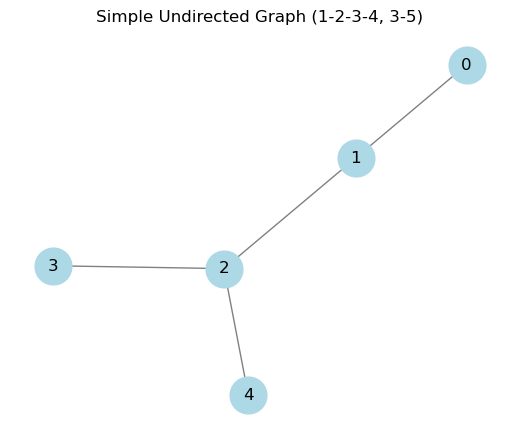

In [3]:
# Define adjacency matrix for 5 nodes (undirected)
adj_matrix = np.zeros((5, 5), dtype=int)
adj_matrix[0, 1] = 1  # 1 - 2
adj_matrix[1, 2] = 1  # 2 - 3
adj_matrix[2, 3] = 1  # 3 - 4
adj_matrix[2, 4] = 1  # 3 - 5

# Make the matrix symmetric for undirected graph
adj_matrix = adj_matrix + adj_matrix.T

# Create undirected graph from adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Plot the graph
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, edge_color='gray')
plt.title('Simple Undirected Graph (1-2-3-4, 3-5)')
plt.show()

In [5]:
node_features = np.array([[1,0,0,0,0]]).T

adj_matrix


array([[0, 1, 0, 0, 0],
       [1, 0, 1, 0, 0],
       [0, 1, 0, 1, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0]])

<h1> Manual GNN architecture </h1>

We'll create an "encoder" and "decoder" that just map identity.
Why? Just to make sure we manipulate the processor part in an abstract space.
It could be done more shortly but let's do it like this now just to get going.

In [ ]:
import torch
import torch.nn as nn
#import torch.nn.functional as F
#from torch_geometric.nn import GCNConv

class SimpleGNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1, num_layers=4):
        super(ProcessorGNN, self).__init__()

        self.encoder = GCNConv(input_dim, hidden_dim)

        # Processor: stack of message-passing layers (with optional residuals)
        self.processor = nn.ModuleList([
            GCNConv(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])

        self.decoder = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        # Encode
        x = self.encoder(x, edge_index)
        x = F.relu(x)

        # Processor (multiple message passing steps)
        for layer in self.processor:
            residual = x
            x = layer(x, edge_index)
            x = F.relu(x + residual)  # residual connection

        # Decode
        out = self.decoder(x, edge_index)
        return out